Example A:

We are going to use 2 layers
optimizer we are going to use SGD
We are going to use without Normalization

Example B:

We are going to use 3 layers
optimizer we are going to use Adam
We are going to use without Normalization

Example C:

We are going to use 2 layers
optimizer we are going to use SGD
We are going to use with Normalization and standardization.


Example A:

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [ ]:
data=pd.read_csv('/content/sample_data/insurance_data.csv')
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [ ]:
data_one_hot=pd.get_dummies(data)
data_one_hot.head(10)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,True,False


In [ ]:
X=data_one_hot.drop('charges',axis=1)
y=data_one_hot['charges']
#print("Features are :")
#X.head()
#y.head()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
tf.random.set_seed(42)
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)])

In [ ]:
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])


In [ ]:
history_model_1=model.fit(X_train,y_train,epochs=50,verbose=0)

In [ ]:
model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 7752.1201 - mae: 7752.1201


[7752.1201171875, 7752.1201171875]

Text(0.5, 1.0, 'Loss vs Epochs')

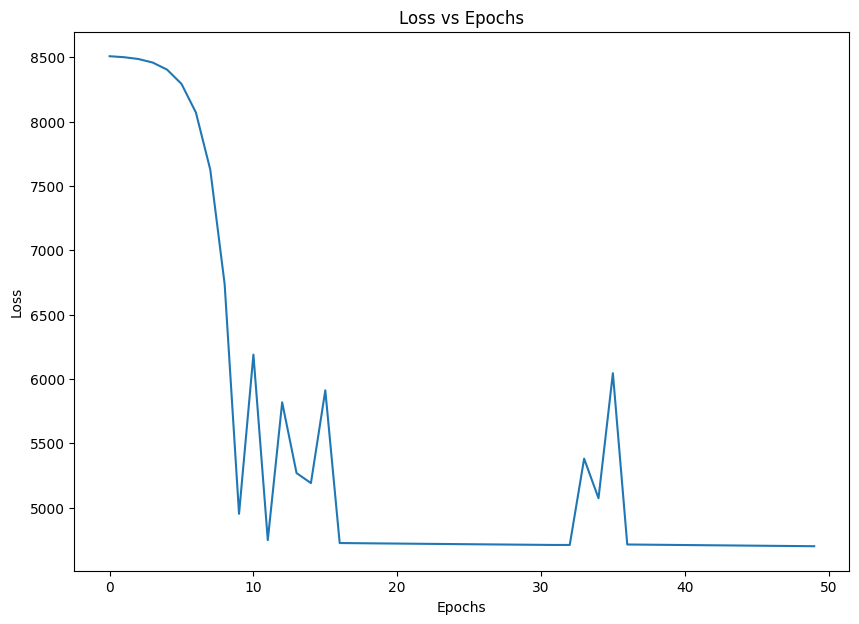

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(history_model_1.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

Example B:

In [ ]:
tf.random.set_seed(42)
model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)])

model_2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

history_model_2=model_2.fit(X_train,y_train,epochs=200,verbose=0)

In [ ]:
model_2.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 7825.7988 - mae: 7825.7988


[7825.798828125, 7825.798828125]

In [ ]:
model_2_loss,model_2_mae=model_2.evaluate(X_test,y_test)
print("Loss : ",model_2_loss)
print("MAE : ",model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 7825.7988 - mae: 7825.7988
Loss :  7825.798828125
MAE :  7825.798828125


Text(0.5, 1.0, 'Loss vs Epochs')

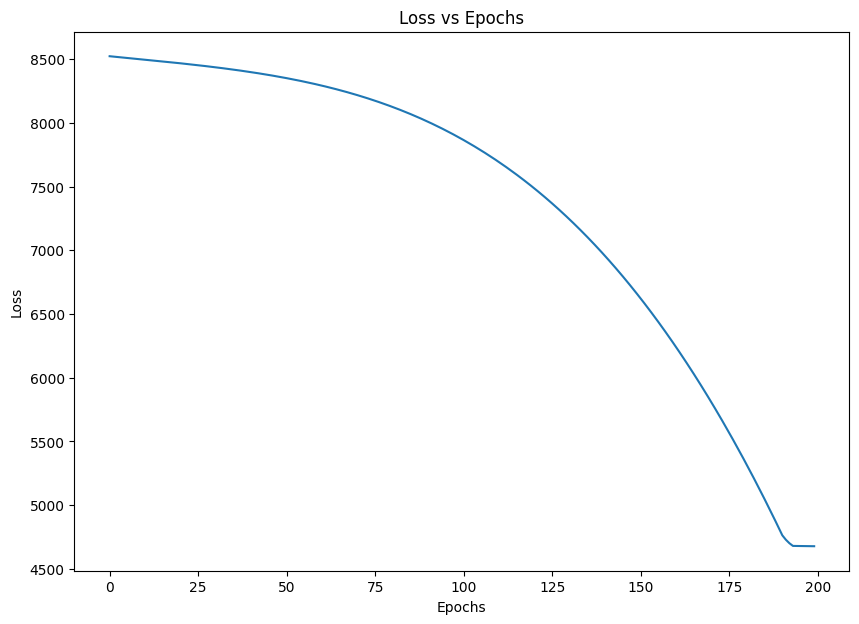

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(history_model_2.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

Example C :

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
ct=make_column_transformer(
    (MinMaxScaler(),["age","bmi","children"]),
    (OneHotEncoder(handle_unknown='ignore'),["sex","smoker","region"])
)

In [ ]:
X=data.drop('charges',axis=1)
y=data['charges']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [ ]:
X_train_normal=ct.transform(X_train)
X_test_normal=ct.transform(X_test)

In [ ]:
# Normalize Data
X_train_normal

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [ ]:
# Original Data
X_train

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [ ]:
print("X-train Shape", X_train.shape)
print("X-train Normal Shape", X_train_normal.shape)


X-train Shape (4, 6)
X-train Normal Shape (4, 8)


In [ ]:
tf.random.set_seed(42)
model_3=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)])

model_3.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

history_model_3=model_3.fit(X_train_normal,y_train,epochs=400,verbose=0)

In [ ]:
model_3.evaluate(X_test_normal,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 8336.1484 - mae: 8336.1484


[8336.1484375, 8336.1484375]

In [ ]:
model_3_loss,model_3_mae=model_3.evaluate(X_test_normal,y_test)
print("Loss : ",model_2_loss)
print("MAE : ",model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8336.1484 - mae: 8336.1484
Loss :  7825.798828125
MAE :  7825.798828125


Text(0.5, 1.0, 'Loss vs Epochs')

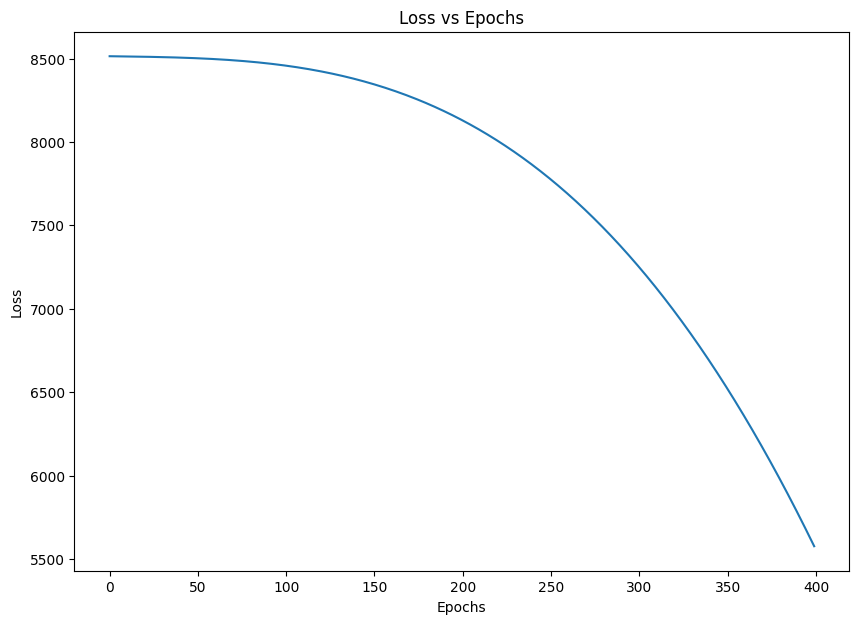

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(history_model_3.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')